# 📡 Análisis de la Empresa en Telecomunicaciones "Megaline"
---
## 📄 Descripción:

En este proyecto, se trabaja como analista para el operador de telecomunicaciones "Megaline", empresa que ofrece dos tarifas de prepago: **Surf** y **Ultimate**.

El departamento comercial busca determinar cuál de las dos tarifas genera mayores ingresos, con el fin de ajustar el presupuesto de publicidad.
---
## 📊 Datos disponibles

Se realiza un análisis preliminar basado en una selección reducida de clientes: **500 usuarios de Megaline**.

Los datos disponibles incluyen:

* 👤 información sobre quiénes son los clientes
* 📍 su ubicación
* 📱 la tarifa que utilizan
* 📞 el número de llamadas realizadas
* 💬 mensajes de texto enviados durante 2018

El análisis consistirá en estudiar el comportamiento de los clientes para identificar cuál de las dos tarifas de prepago reporta mayores ingresos.
---
## 🎯 Objetivo del análisis

De manera más desglosada, el objetivo es detectar patrones de comportamiento de los usuarios que contrataron diferentes tarifas/planes de prepago (en este caso Surf y Ultimate), esto es:

* observar, por ejemplo, qué servicios se utilizan más en cada caso (mensajería, internet o llamadas)
* además de hacer pruebas de hipótesis para saber si existen diferencias estadísticamente significativas entre las medias de ingreso de dos muestras delimitadas según múltiples criterios, como el lugar de residencia o el mismo plan al que están suscritos los usuarios
---
## 🧹 Preprocesamiento de datos

Para ello primero será necesario hacer un correcto preprocesamiento de los datos:

* revisando que no haya valores ausentes ni duplicados
* que los datos estén en un formato correcto
* a la par que enriquecer los dataframes con nuevas columnas que contengan información extraida de las ya existentes, pero que nos ayude a un mejor manejo de las variables y cálculos matemáticos
---
## 🔍 Análisis exploratorio y estadístico

Luego será necesario hacer observaciones exploratorias, probablemente incluyendo ejercicios de estadística descriptiva para terminar con el análisis propiamente dicho, el cual incluyo los primeros pasos de la estadística inferencial y probabilidad.
---
## 📈 Visualización de datos

A todo ello, por supuesto, será imprescindible añadir una parte de visualización para interpretar de manera más sencilla el conjunto de datos.

## 1. Preprocesamiento de los Datos

In [ ]:
# Cargar todas las librerías
# Es importante desde un inicio cargar toda la pila de librerías que se ha aprendido hasta ahora, pues cada una fungirá 
# un papel crucial desde el preprocesamiento hasta el análisis de los datos. 
import pandas as pd
from scipy import stats as st
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns 
import math

In [ ]:
# Cargo los archivos de datos en diferentes DataFrames

# En este caso, no fue necesario añadir ningún parametro (como 'sep=' o 'header='), ya que los dataframes se encuentran ordenados.
users = pd.read_csv('/datasets/megaline_users.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')
calls = pd.read_csv('/datasets/megaline_calls.csv')

In [ ]:
# Imprimo la información general/resumida sobre el dataframe de las tarifas
print(plans.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes
None


In [ ]:
# Imprimo cómo se ve el dataframe de las tarifas
plans

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


En este caso, considero que todos las variables están correctamente dispuestos. Ninguna columna necesita cambiar su formato, pues el nombre de cada una está escrito en minusculas, así como tampoco el tipo de datos que reflejan.  

In [ ]:
# Imprimo la información general/resumida sobre el dataframe de usuarios
print(users.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB
None


In [ ]:
# Imprimo una muestra de datos para usuarios
users.head(10)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN
5,1005,Livia,Shields,31,"Dallas-Fort Worth-Arlington, TX MSA",2018-11-29,surf,NaN
6,1006,Jesusa,Bradford,73,"San Francisco-Oakland-Berkeley, CA MSA",2018-11-27,ultimate,2018-12-18
7,1007,Eusebio,Welch,42,"Grand Rapids-Kentwood, MI MSA",2018-07-11,surf,NaN
8,1008,Emely,Hoffman,53,"Orlando-Kissimmee-Sanford, FL MSA",2018-08-03,ultimate,NaN
9,1009,Gerry,Little,19,"San Jose-Sunnyvale-Santa Clara, CA MSA",2018-04-22,surf,NaN


Es importante cambiar la columna "reg_date" y "churn_date" a formato "datetime". Además, hay que tratar los valores ausentes. Una solución podría ser reemplazarlos por "Unknown", aunque esto contradiría el formato "datetime" al cual queremos cambiar la columna. En consecuencia, quizás la mejor opción sea dejar los valores ausentes tal como están, sin modificación. 

In [ ]:
# Basándonos en la nota anterior, corrijo el formato de las variables mencionadas. 
users['reg_date'] = pd.to_datetime(users['reg_date'], format='%Y-%m-%d')
users['churn_date'] = pd.to_datetime(users['churn_date'], format='%Y-%m-%d')

In [ ]:
# Enriquezco los datos a partir de la creación de columnas exclusivas para año, mes y día. Esto es 
# aplicación de lo que se suele conocer como "ingeniería de características".
users['year'] = users['reg_date'].dt.year
users['month'] = users['reg_date'].dt.month
users['day'] = users['reg_date'].dt.day

users


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,month,day
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,2018,12,24
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,2018,8,13
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT,2018,10,21
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaT,2018,1,28
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaT,2018,5,23
...,...,...,...,...,...,...,...,...,...,...,...
495,1495,Fidel,Sharpe,67,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-09-04,surf,NaT,2018,9,4
496,1496,Ariel,Shepherd,49,"New Orleans-Metairie, LA MSA",2018-02-20,surf,NaT,2018,2,20
497,1497,Donte,Barrera,49,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-12-10,ultimate,NaT,2018,12,10
498,1498,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,surf,NaT,2018,2,4


In [ ]:
# Imprimo la información general/resumida sobre el dataframe de las llamadas
print(calls.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
None


In [ ]:
# Imprimo una muestra de datos para las llamadas
calls.head(10)

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22
5,1000_388,1000,2018-12-31,2.20
6,1000_510,1000,2018-12-27,5.75
7,1000_521,1000,2018-12-28,14.18
8,1000_530,1000,2018-12-28,5.77
9,1000_544,1000,2018-12-26,4.40


Hay que cambiar la columna "call_date" a formato "datetime" y considero que debe modificarse igualmente la columna "id" a "int64"

In [ ]:
# Corrijo los datos de acuerdo con la nota anterior.
calls['call_date'] = pd.to_datetime(calls['call_date'], format='%Y-%m-%d')

# calls['id'] = calls['id'].astype('int')
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB


In [ ]:
# Enriquezco los datos con ingenierie de características, en particular con la creación de columnas 
# exclusivas para año, mes y día. Por otro lado, redondeo los valores de la variable 'duration' y guardo 
# el resultado en una nueva columna. 
calls['duration_rounded'] = calls['duration'].apply(math.ceil)

calls['year'] = calls['call_date'].dt.year
calls['month'] = calls['call_date'].dt.month
calls['day'] = calls['call_date'].dt.day

calls

,id,user_id,call_date,duration,duration_rounded,year,month,day
0,1000_93,1000,2018-12-27,8.52,9,2018,12,27
1,1000_145,1000,2018-12-27,13.66,14,2018,12,27
2,1000_247,1000,2018-12-27,14.48,15,2018,12,27
3,1000_309,1000,2018-12-28,5.76,6,2018,12,28
4,1000_380,1000,2018-12-30,4.22,5,2018,12,30
...,...,...,...,...,...,...,...,...
137730,1499_199,1499,2018-11-21,8.72,9,2018,11,21
137731,1499_200,1499,2018-10-20,10.89,11,2018,10,20
137732,1499_201,1499,2018-09-21,8.12,9,2018,9,21
137733,1499_202,1499,2018-10-10,0.37,1,2018,10,10


In [ ]:
# Imprimo la información general/resumida sobre el DataFrame de los mensajes
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [ ]:
# Imprimo una muestra de datos para los mensajes
messages.head(10)

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26
5,1000_346,1000,2018-12-29
6,1000_386,1000,2018-12-30
7,1000_413,1000,2018-12-31
8,1000_502,1000,2018-12-27
9,1000_525,1000,2018-12-28


Hay que cambiar la columna "message_date" a formato "datetime".

In [ ]:
# Implemento las correcciones de la nota anterior.
messages['message_date'] = pd.to_datetime(messages['message_date'], format='%Y-%m-%d')
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB


In [ ]:
# Enriquezco los datos con ingeniería de características. Creo de igual manera columnas 
# exclusivas para año, mes y día
messages['year'] = messages['message_date'].dt.year
messages['month'] = messages['message_date'].dt.month
messages['day'] = messages['message_date'].dt.day

messages

,id,user_id,message_date,year,month,day
0,1000_125,1000,2018-12-27,2018,12,27
1,1000_160,1000,2018-12-31,2018,12,31
2,1000_223,1000,2018-12-31,2018,12,31
3,1000_251,1000,2018-12-27,2018,12,27
4,1000_255,1000,2018-12-26,2018,12,26
...,...,...,...,...,...,...
76046,1497_526,1497,2018-12-24,2018,12,24
76047,1497_536,1497,2018-12-24,2018,12,24
76048,1497_547,1497,2018-12-31,2018,12,31
76049,1497_558,1497,2018-12-24,2018,12,24


In [ ]:
# Imprimo la información general/resumida sobre el dataframe de internet
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [ ]:
# Imprimo una muestra de datos para el tráfico de internet
internet.head(10)

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22
5,1001_0,1001,2018-08-24,284.68
6,1001_3,1001,2018-12-09,656.04
7,1001_4,1001,2018-11-04,16.97
8,1001_10,1001,2018-11-27,135.18
9,1001_15,1001,2018-12-13,761.92


Hay que cambiar la columna "session_date" a formato "datetime".

In [ ]:
# Implemento las correciones de la nota anterior. 
internet['session_date'] = pd.to_datetime(internet['session_date'], format='%Y-%m-%d')
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB


In [ ]:
# Enriquezco los datos con ingeniería de características. En particular, creo columnas 
# exclusivas para año, mes y día.
internet['year'] = internet['session_date'].dt.year
internet['month'] = internet['session_date'].dt.month
internet['day'] = internet['session_date'].dt.day

internet

,id,user_id,session_date,mb_used,year,month,day
0,1000_13,1000,2018-12-29,89.86,2018,12,29
1,1000_204,1000,2018-12-31,0.00,2018,12,31
2,1000_379,1000,2018-12-28,660.40,2018,12,28
3,1000_413,1000,2018-12-26,270.99,2018,12,26
4,1000_442,1000,2018-12-27,880.22,2018,12,27
...,...,...,...,...,...,...,...
104820,1499_215,1499,2018-10-20,218.06,2018,10,20
104821,1499_216,1499,2018-12-30,304.72,2018,12,30
104822,1499_217,1499,2018-09-22,292.75,2018,9,22
104823,1499_218,1499,2018-12-07,0.00,2018,12,7


## 2. Análisis Exploratorio de los Datos

In [ ]:
# A continuación se realizarán algunas exploraciones numéricas y descriptivas de las tarifas.
# Sin embargo, para ello es necesario imprimir una vez más la información del dataframe y asegurarse
# de que todo esté en orden y sea claro.
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [ ]:
# Ahora que los datos están limpios, calcularé el número de llamadas hechas por cada usuario al mes. 
# Esto facilitará mucho el análisis posterior. 
calls_per_month = calls.groupby(['month', 'user_id'])['id'].count()
calls_per_month

month  user_id
1      1042       18
       1077       42
       1185       23
       1196       42
       1214        5
                  ..
12     1495       65
       1496       40
       1497       54
       1498       39
       1499       65
Name: id, Length: 2258, dtype: int64

In [ ]:
# Ahora calculo la cantidad de minutos usados por cada usuario al mes. 
calls_per_minute = calls.groupby(['month', 'user_id'])['duration_rounded'].sum()
calls_per_minute

month  user_id
1      1042       114
       1077       290
       1185       181
       1196       287
       1214        16
                 ... 
12     1495       492
       1496       294
       1497       300
       1498       339
       1499       496
Name: duration_rounded, Length: 2258, dtype: int64

In [ ]:
# Calculo el número de mensajes enviados por cada usuario al mes.
messages_per_user = messages.groupby(['month', 'user_id'])['id'].count()
messages_per_user

month  user_id
1      1077       37
       1196       23
       1214        2
       1362       21
2      1028       12
                  ..
12     1491       43
       1492       37
       1494       33
       1496       11
       1497       50
Name: id, Length: 1806, dtype: int64

In [ ]:
# Calculo el volumen del tráfico de Internet usado por cada usuario al mes. 
internet_per_month = internet.groupby(['month', 'user_id'])['mb_used'].sum()
internet_per_month

month  user_id
1      1042        1854.93
       1077       10635.64
       1185        6812.77
       1196        8908.61
       1214        1315.35
                    ...   
12     1495       24097.40
       1496       16438.99
       1497       11106.55
       1498       23137.69
       1499       22059.21
Name: mb_used, Length: 2277, dtype: float64

[Junta los datos agregados en un DataFrame para que haya un registro que represente lo que consumió un usuario único en un mes determinado.]

In [ ]:
# Fusiono los datos de llamadas, minutos, mensajes e internet con base en "user_id" y "month".
calls_count = calls_per_month.reset_index()
calls_duration = calls_per_minute.reset_index()
messages_count = messages_per_user.reset_index()
internet_usage = internet_per_month.reset_index()

merged_data = calls_count.merge(calls_duration, on=['user_id', 'month'], how='outer')
merged_data = merged_data.merge(messages_count, on=['user_id', 'month'], how='outer')
merged_data = merged_data.merge(internet_usage, on=['user_id', 'month'], how='outer')

merged_data = merged_data.rename(columns={
    'id_x': 'call_id',
    'id_y': 'message_id'
})

merged_data

,month,user_id,call_id,duration_rounded,message_id,mb_used
0,1,1042,18.0,114.0,NaN,1854.93
1,1,1077,42.0,290.0,37.0,10635.64
2,1,1185,23.0,181.0,NaN,6812.77
3,1,1196,42.0,287.0,23.0,8908.61
4,1,1214,5.0,16.0,2.0,1315.35
...,...,...,...,...,...,...
2288,12,1194,NaN,NaN,56.0,31088.49
2289,12,1204,NaN,NaN,78.0,36730.05
2290,12,1349,NaN,NaN,61.0,13039.91
2291,6,1311,NaN,NaN,NaN,1498.83


In [ ]:
# Añado la información de la tarifa, también con la función "merge"
merged_data

merged_data = merged_data.merge(users[['user_id', 'plan']], on='user_id', how='left')
merged_data

merged_data = merged_data.merge(plans, left_on='plan', right_on='plan_name', how='left')
merged_data = merged_data.drop(columns=['plan'])

In [30]:
merged_data.columns
merged_data

,month,user_id,call_id,duration_rounded,message_id,mb_used,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,1,1042,18.0,114.0,NaN,1854.93,50,15360,500,20,10,0.03,0.03,surf
1,1,1077,42.0,290.0,37.0,10635.64,1000,30720,3000,70,7,0.01,0.01,ultimate
2,1,1185,23.0,181.0,NaN,6812.77,1000,30720,3000,70,7,0.01,0.01,ultimate
3,1,1196,42.0,287.0,23.0,8908.61,1000,30720,3000,70,7,0.01,0.01,ultimate
4,1,1214,5.0,16.0,2.0,1315.35,1000,30720,3000,70,7,0.01,0.01,ultimate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2288,12,1194,NaN,NaN,56.0,31088.49,50,15360,500,20,10,0.03,0.03,surf
2289,12,1204,NaN,NaN,78.0,36730.05,1000,30720,3000,70,7,0.01,0.01,ultimate
2290,12,1349,NaN,NaN,61.0,13039.91,50,15360,500,20,10,0.03,0.03,surf
2291,6,1311,NaN,NaN,NaN,1498.83,1000,30720,3000,70,7,0.01,0.01,ultimate


In [ ]:
# Calculo los ingresos mensuales por usuario.

# PASO 1: Verificar las columnas disponibles
print("Columnas disponibles:")
print(merged_data.columns.tolist())
print("\nPrimeras filas para entender la estructura:")
print(merged_data.head())

# PASO 2: Llenar valores NaN con 0 (usuarios que no usaron el servicio).
# A pesar de que en los comentarios posteriores se pongan comentarios en rojo señalando que esta parte no es del todo correcta, me gustaría argumentar que en realidad sí lo es.
# Rellenar los valores ausentes con "0" tiene sentido y no afecta a la estructura de los datos, además de que permite proseguir con el cálculo de los ingresos mensuales por usuario
# de lo contrario se arroja un error. 
merged_data['call_id'] = merged_data['call_id'].fillna(0)
merged_data['duration_rounded'] = merged_data['duration_rounded'].fillna(0)
merged_data['message_id'] = merged_data['message_id'].fillna(0)
merged_data['mb_used'] = merged_data['mb_used'].fillna(0)

# PASO 3: Convertir MB a GB y redondear hacia arriba
merged_data['gb_used'] = merged_data['mb_used'].apply(lambda x: math.ceil(x / 1024))

# PASO 4: Crear la columna de GB incluidos (convertir MB incluidos a GB)
merged_data['gb_included'] = merged_data['mb_per_month_included'] / 1024
print("GB incluidos por plan:")
print(merged_data[['plan_name', 'gb_included']].drop_duplicates())

# PASO 5: Calcular excesos por categoría
# Excesos de minutos
merged_data['minutos_extra'] = merged_data.apply(
    lambda row: max(0, row['duration_rounded'] - row['minutes_included']), axis=1
)

# Excesos de mensajes
merged_data['mensajes_extra'] = merged_data.apply(
    lambda row: max(0, row['message_id'] - row['messages_included']), axis=1
)

# Excesos de GB
merged_data['gb_extra'] = merged_data.apply(
    lambda row: max(0, row['gb_used'] - row['gb_included']), axis=1
)

# PASO 6: Calcular cargos por excesos
merged_data['cargos_minutos'] = merged_data['minutos_extra'] * merged_data['usd_per_minute']
merged_data['cargos_mensajes'] = merged_data['mensajes_extra'] * merged_data['usd_per_message']
merged_data['cargos_internet'] = merged_data['gb_extra'] * merged_data['usd_per_gb']

# PASO 7: Calcular ingreso total por usuario/mes
merged_data['ingreso_mensual'] = (
    merged_data['usd_monthly_pay'] + 
    merged_data['cargos_minutos'] + 
    merged_data['cargos_mensajes'] + 
    merged_data['cargos_internet']
)

# PASO 8: Verificar algunos resultados
print("\nPrimeros 10 resultados:")
print(merged_data[['user_id', 'month', 'plan_name', 'ingreso_mensual']].head(10))

# PASO 9: Verificar estadísticas básicas
print("\nEstadísticas de ingresos por plan:")
print(merged_data.groupby('plan_name')['ingreso_mensual'].describe())

Columnas disponibles:
['month', 'user_id', 'call_id', 'duration_rounded', 'message_id', 'mb_used', 'messages_included', 'mb_per_month_included', 'minutes_included', 'usd_monthly_pay', 'usd_per_gb', 'usd_per_message', 'usd_per_minute', 'plan_name']

Primeras filas para entender la estructura:
   month  user_id  call_id  duration_rounded  message_id   mb_used  \
0      1     1042     18.0             114.0         NaN   1854.93   
1      1     1077     42.0             290.0        37.0  10635.64   
2      1     1185     23.0             181.0         NaN   6812.77   
3      1     1196     42.0             287.0        23.0   8908.61   
4      1     1214      5.0              16.0         2.0   1315.35   

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   
2               1000                  30720              3000   
3               1000      

In [ ]:
# Se visualiza con un mejor formato el dataframe
merged_data

,month,user_id,call_id,duration_rounded,message_id,mb_used,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,...,plan_name,gb_used,gb_included,minutos_extra,mensajes_extra,gb_extra,cargos_minutos,cargos_mensajes,cargos_internet,ingreso_mensual
0,1,1042,18.0,114.0,0.0,1854.93,50,15360,500,20,...,surf,2,15.0,0.0,0.0,0.0,0.0,0.00,0.0,20.00
1,1,1077,42.0,290.0,37.0,10635.64,1000,30720,3000,70,...,ultimate,11,30.0,0.0,0.0,0.0,0.0,0.00,0.0,70.00
2,1,1185,23.0,181.0,0.0,6812.77,1000,30720,3000,70,...,ultimate,7,30.0,0.0,0.0,0.0,0.0,0.00,0.0,70.00
3,1,1196,42.0,287.0,23.0,8908.61,1000,30720,3000,70,...,ultimate,9,30.0,0.0,0.0,0.0,0.0,0.00,0.0,70.00
4,1,1214,5.0,16.0,2.0,1315.35,1000,30720,3000,70,...,ultimate,2,30.0,0.0,0.0,0.0,0.0,0.00,0.0,70.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2288,12,1194,0.0,0.0,56.0,31088.49,50,15360,500,20,...,surf,31,15.0,0.0,6.0,16.0,0.0,0.18,160.0,180.18
2289,12,1204,0.0,0.0,78.0,36730.05,1000,30720,3000,70,...,ultimate,36,30.0,0.0,0.0,6.0,0.0,0.00,42.0,112.00
2290,12,1349,0.0,0.0,61.0,13039.91,50,15360,500,20,...,surf,13,15.0,0.0,11.0,0.0,0.0,0.33,0.0,20.33
2291,6,1311,0.0,0.0,0.0,1498.83,1000,30720,3000,70,...,ultimate,2,30.0,0.0,0.0,0.0,0.0,0.00,0.0,70.00


In [ ]:
# Ahora pasaré a explorar el comportamiento del usuario. Calcularé algunas estadísticas descriptivas 
# para los datos agregados y fusionados que nos sean útiles y que muestren un panorama general. 
# Crearé gráficos útiles para facilitar la comprensión. Dado que la tarea principal es comparar 
# las tarifas y decidir cuál es más rentable, las estadísticas y gráficas deben calcularse por tarifa.

# Entonces, en primer lugar, comparo la duración promedio de llamadas por cada plan y por cada mes. 
# Trazo un gráfico de barras para visualizarlo.
calls_duration_mean = merged_data.groupby(['month', 'plan_name'])['duration_rounded'].mean().unstack(fill_value=0)
calls_duration_mean = calls_duration_mean.reset_index()
calls_duration_mean

calls_duration_mean = calls_duration_mean.rename_axis('', axis=1)
calls_duration_mean

,month,surf,ultimate
0,1,203.000000,193.500000
1,2,297.000000,403.142857
2,3,330.000000,304.250000
3,4,351.540000,336.857143
4,5,399.584416,406.241379
5,6,431.298969,370.957447
6,7,449.983471,427.067797
7,8,410.111111,421.436620
8,9,414.226804,437.511628
9,10,429.729958,450.735849


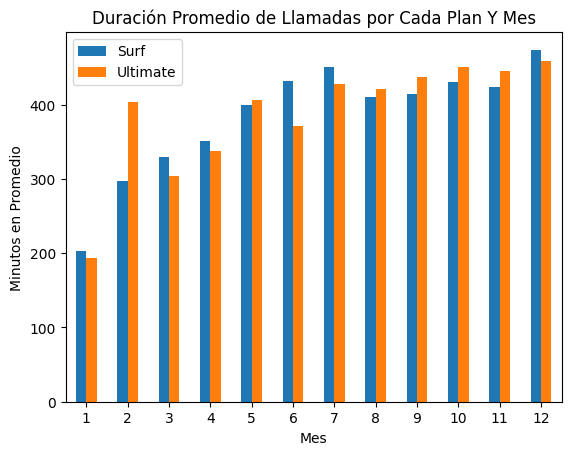

In [34]:
calls_duration_mean.plot(
        x='month',
        kind = 'bar',
        title='Duración Promedio de Llamadas por Cada Plan Y Mes',
        xlabel='Mes',
        ylabel='Minutos en Promedio',
        rot= 360)

plt.legend(['Surf', 'Ultimate'])
plt.show()

In [ ]:
# Comparo el número de minutos mensuales que necesitan los usuarios de cada plan. Trazo un histograma.
minutos_por_plan = merged_data.groupby(['user_id', 'month', 'plan_name'])['duration_rounded'].sum()
minutos_por_plan = minutos_por_plan.reset_index()
minutos_por_plan.head()


,user_id,month,plan_name,duration_rounded
0,1000,12,ultimate,124.0
1,1001,8,surf,182.0
2,1001,9,surf,315.0
3,1001,10,surf,393.0
4,1001,11,surf,426.0


In [ ]:
# Separo la duración de minutos consumidos por plan
surf_minutos = minutos_por_plan[minutos_por_plan['plan_name'] == 'surf']['duration_rounded']
surf_minutos.head()



1    182.0
2    315.0
3    393.0
4    426.0
5    412.0
Name: duration_rounded, dtype: float64

In [37]:
ultimate_minutos = minutos_por_plan[minutos_por_plan['plan_name'] == 'ultimate']['duration_rounded']
ultimate_minutos.head()


0     124.0
19     10.0
20     59.0
26    476.0
27    446.0
Name: duration_rounded, dtype: float64

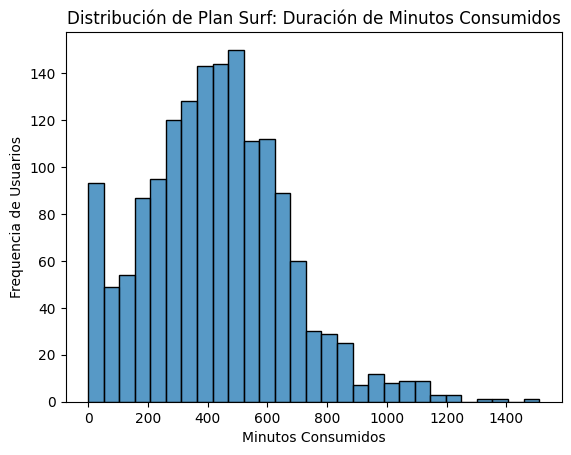

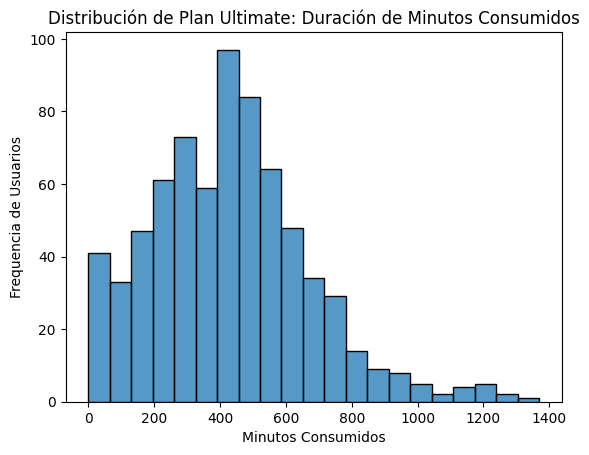

In [ ]:
# Crear histogramas
sns.histplot(surf_minutos)
plt.title('Distribución de Plan Surf: Duración de Minutos Consumidos')
plt.xlabel('Minutos Consumidos')
plt.ylabel('Frequencia de Usuarios')
plt.show()

sns.histplot(ultimate_minutos)
plt.title('Distribución de Plan Ultimate: Duración de Minutos Consumidos')
plt.xlabel('Minutos Consumidos')
plt.ylabel('Frequencia de Usuarios')
plt.show()

In [ ]:
# Calculo la media y la variable de la duración de las llamadas para averiguar si los usuarios 
# de los distintos planes se comportan de forma diferente al realizar sus llamadas.

# Media de duración por plan
media_por_plan = merged_data.groupby('plan_name')['duration_rounded'].mean()
print("Media de duración por plan:")
print(media_por_plan)

# Varianza de duración por plan
varianza_por_plan = merged_data.groupby('plan_name')['duration_rounded'].var()
print("Varianza de duración por plan:")
print(varianza_por_plan)

Media de duración por plan:
plan_name
surf        428.749523
ultimate    430.450000
Name: duration_rounded, dtype: float64
Varianza de duración por plan:
plan_name
surf        54968.279461
ultimate    57844.464812
Name: duration_rounded, dtype: float64


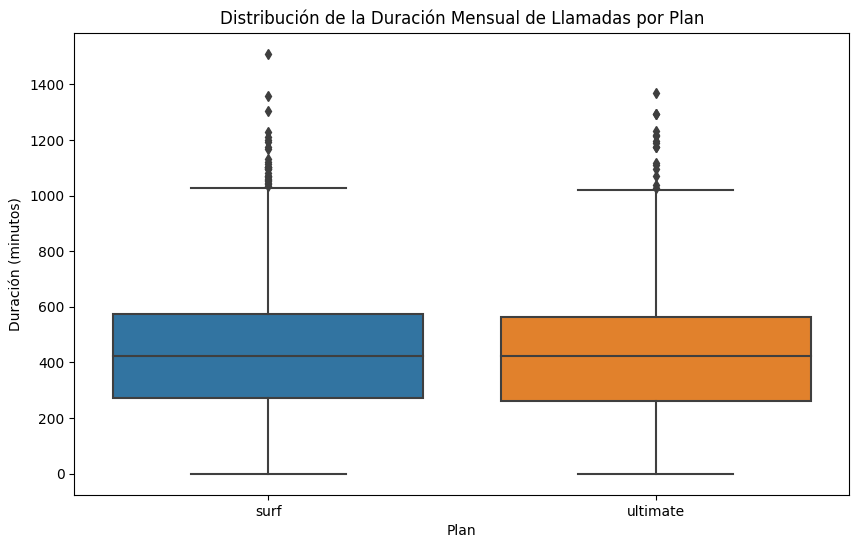

In [ ]:
# Trazo un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

plt.figure(figsize=(10, 6))
sns.boxplot(data=merged_data, x='plan_name', y='duration_rounded')
plt.title('Distribución de la Duración Mensual de Llamadas por Plan')
plt.xlabel('Plan')
plt.ylabel('Duración (minutos)')
plt.show()


El comportamiento de los usuarios respecto a las llamadas no varía significativamente. Como lo muestra la gráfica de barras, la duración promedio de minutos consumidos por cada plan a lo largo de los 12 meses que comprendió 2018 es muy similar. Salvo en Febrero, que corresponde al segundo mes, hubo un consumo significativamente mayor en el plan ultimate respecto al plan surf; pero en el resto se mantuvo muy similar. Por otro lado, los histogramas señalan que, en el plan surf, hay una mayor cantidad de usuarios que sobrepasan el límite de minutos incluidos en su plan (500). De hecho, la gran mayoría de los usuarios del plan ultimate prácticamente no llegan a consumir ni la mitad de minutos incluidos en su plan (3000). A pesar de todo, ambos tienen una media de minutos consumidos muy parecida (surf: 404.7 y ultimate: 406.1) al igual que su variación, si bien el plan surf suele mostrar más valores atípicos, como lo representan muy bien los gráficos de caja.


In [ ]:
# Ahora comparo el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
numero_mensajes = merged_data.groupby(['month', 'plan_name'])['message_id'].count().unstack(fill_value=0)
numero_mensajes = numero_mensajes.reset_index()

numero_mensajes = numero_mensajes.rename_axis('', axis=1)
numero_mensajes

,month,surf,ultimate
0,1,2,4
1,2,9,7
2,3,23,12
3,4,50,21
4,5,77,29
5,6,97,47
6,7,121,59
7,8,162,71
8,9,194,86
9,10,237,106


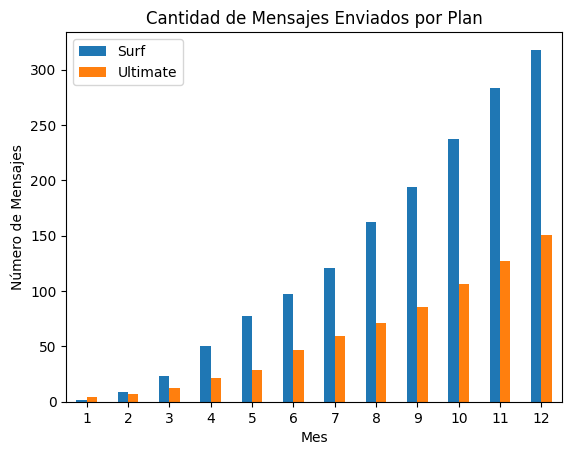

In [ ]:
numero_mensajes.plot(
        x='month',
        kind = 'bar',
        title='Cantidad de Mensajes Enviados por Plan',
        xlabel='Mes',
        ylabel='Número de Mensajes',
        rot= 360
)

plt.legend(['Surf', 'Ultimate'])
plt.show()

Hay una clara diferencia en el comportamiento de los usuarios respecto al número de mensajes que suelen enviar cada mes. El plan surf posee la clara ventaja respecto al plan ultimate. Además de que la brecha se va acrecentando exponencialmente conforme pasan los meses. Para Diciembre, es decir, el mes 12, la cantidad de mensajes del plan surf ya había superado por más del doble la correspondiente del plan ultimate. 

In [ ]:
# Comparo la cantidad de tráfico de Internet consumido por usuarios por plan
cantidad_internet_consumido = merged_data.groupby(['user_id', 'plan_name'])['mb_used'].sum().reset_index()
cantidad_internet_consumido

,user_id,plan_name,mb_used
0,1000,ultimate,1901.47
1,1001,surf,80437.94
2,1002,surf,40293.33
3,1003,surf,27044.14
4,1004,surf,156352.81
...,...,...,...
485,1495,surf,98890.96
486,1496,surf,64268.64
487,1497,ultimate,11106.55
488,1498,surf,227525.13


In [45]:
internet_surf = cantidad_internet_consumido[cantidad_internet_consumido['plan_name'] == 'surf']['mb_used'].describe()
internet_ultimate = cantidad_internet_consumido[cantidad_internet_consumido['plan_name'] == 'ultimate']['mb_used'].describe()

print(internet_surf)
print(internet_ultimate)

count       333.000000
mean      78216.756547
std       59805.965905
min           0.000000
25%       30068.850000
50%       63050.670000
75%      117074.610000
max      312518.640000
Name: mb_used, dtype: float64
count       157.000000
mean      78946.393503
std       66549.275075
min         233.170000
25%       28925.070000
50%       59418.940000
75%      106827.620000
max      390159.350000
Name: mb_used, dtype: float64


En general, el consumo de internet por parte de los usuarios no difiere prácticamente. Tan sólo hay una brecha de 700 megabytes aproximadamente entre cada uno. Por otro lado, sí que hay mayor dispersión en el plan ultimate respecto al surf, demostrando este último mayor consistencia en el consumo de tráfico de internet. 


In [ ]:
# Procedo en esta parte a calcular los ingresos mensuales por plan.

# Estadísticas descriptivas por plan.
ingresos_por_plan = merged_data.groupby('plan_name')['ingreso_mensual'].describe()
print(ingresos_por_plan)

            count       mean        std   min   25%    50%    75%     max
plan_name                                                                
surf       1573.0  60.706408  55.388042  20.0  20.0  40.36  80.36  590.37
ultimate    720.0  72.313889  11.395108  70.0  70.0  70.00  70.00  182.00


In [ ]:
# Separo los datos de ingreso mensual por usuario y plan para gráficos.

ingresos_por_plan_2 = merged_data.groupby(['plan_name', 'user_id'])['ingreso_mensual'].sum() 
ingresos_por_plan_2 = ingresos_por_plan_2.reset_index()
print(ingresos_por_plan_2)
surf_ingresos = ingresos_por_plan_2[ingresos_por_plan_2['plan_name'] == 'surf']['ingreso_mensual']
print(surf_ingresos)
ultimate_ingresos = ingresos_por_plan_2[ingresos_por_plan_2['plan_name'] == 'ultimate']['ingreso_mensual']
print(ultimate_ingresos)

    plan_name  user_id  ingreso_mensual
0        surf     1001           250.09
1        surf     1002           100.00
2        surf     1003           158.12
3        surf     1004           610.00
4        surf     1005            40.00
..        ...      ...              ...
485  ultimate     1482           210.00
486  ultimate     1487            70.00
487  ultimate     1490           686.00
488  ultimate     1493           350.00
489  ultimate     1497            70.00

[490 rows x 3 columns]
0      250.09
1      100.00
2      158.12
3      610.00
4       40.00
        ...  
328    183.75
329    473.30
330    140.00
331    850.00
332    220.00
Name: ingreso_mensual, Length: 333, dtype: float64
333     70.0
334    154.0
335    210.0
336    490.0
337     70.0
       ...  
485    210.0
486     70.0
487    686.0
488    350.0
489     70.0
Name: ingreso_mensual, Length: 157, dtype: float64


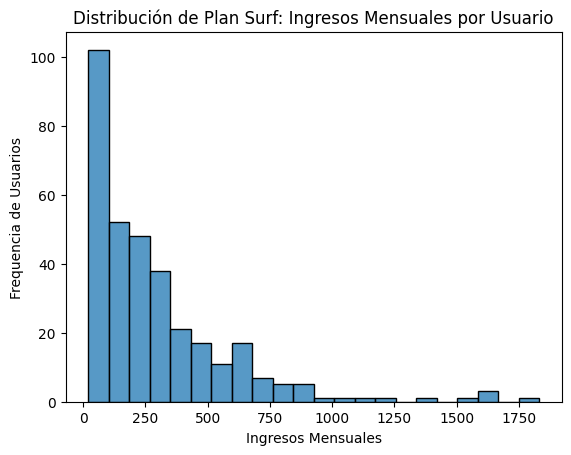

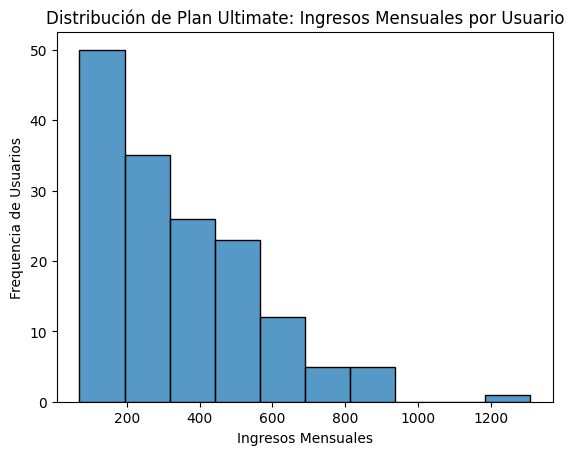

In [ ]:
sns.histplot(surf_ingresos)
plt.title('Distribución de Plan Surf: Ingresos Mensuales por Usuario')
plt.xlabel('Ingresos Mensuales')
plt.ylabel('Frequencia de Usuarios')
plt.show()

sns.histplot(ultimate_ingresos)
plt.title('Distribución de Plan Ultimate: Ingresos Mensuales por Usuario')
plt.xlabel('Ingresos Mensuales')
plt.ylabel('Frequencia de Usuarios')
plt.show()

Los histogramas demuestran que los ingresos del plan surf son significativamente mayores a los del plan ultimate, gracias en parte al número de usuarios registrados en cada uno, pero también a la cantidad de dinero que generan estos mensualmente. Esto quiere decir que la población de usuarios del plan surf representa la principal fuente de activos de la empresa.

## 4. Prueba de Hipótesis

In [ ]:
# En esta sección pasaré a probar la hipótesis de que son diferentes los ingresos promedio 
# procedentes de los usuarios de los planes Ultimate y Surf. Es importante mencionar que 
# nuestra prueba de hipótesis es bilateral, ya que no se pretende comprobar si los ingresos promedio
# de algún plan son mayores o menores. La hipótesis nula en este sentido será que que los ingresos
# promedio de los planes son los mismos, en tanto que la hipótesis alternativa afirma que sí 
# hay diferencia.

usuarios_surf = merged_data[merged_data['plan_name'] == 'surf']['ingreso_mensual']
usuarios_ultimate = merged_data[merged_data['plan_name'] == 'ultimate']['ingreso_mensual']

alpha = .05

results = st.ttest_ind(usuarios_surf, usuarios_ultimate, equal_var = False)

pvalue = results.pvalue

if pvalue < alpha:
    print('se rechaza la hipótesis nula')
else: 
    print('no se rechaza la hipótesis nula')


se rechaza la hipótesis nula


In [ ]:
# Ahora paso a realizar la rueba la hipótesis de que el ingreso promedio de los usuarios 
# del área NY-NJ es diferente al de los usuarios de otras regiones. En este caso también se hace
# una prueba bilateral. La hipótesis nula es que el ingreso promedio de los usuarios del área NY-NJ
# es el mismo que el de los usuarios de otras regiones, mientras que la alternativa afirma que sí hay 
# diferencia entre ellos. 
merged_data = merged_data.merge(users[['user_id', 'city']], on='user_id', how='outer')
merged_data.head(5)

# Identificar usuarios de NY-NJ
ny_nj_users = merged_data[merged_data['city'].str.contains('New York-Newark-Jersey City', na=False)]
other_users = merged_data[~merged_data['city'].str.contains('New York-Newark-Jersey City', na=False)]

# Obtener los ingresos de cada grupo
ingresos_ny_nj = ny_nj_users['ingreso_mensual']
ingresos_otras_regiones = other_users['ingreso_mensual']

# Hacer la prueba de hipótesis: 
alpha = .05

results_2 = st.ttest_ind(ingresos_ny_nj, ingresos_otras_regiones, equal_var=False)

pvalor = results_2.pvalue

if pvalor < alpha:
    print('se rechaza la hipótesis nula')
else: 
    print('no se rechaza la hipótesis nula')

no se rechaza la hipótesis nula


# Conclusiones
---
En el plano del comportamiento de los usuarios, es posible identificar algunas conclusiones centrales. En primer lugar, el plan surf aventaja ligeramente en consumo de minutos de llamadas telefónicas al plan ultimate, salvo en febrero, que representa el segundo mes del año. Por otro lado, los promedios de consumo de ambos planes tienden a incrementarse conforme pasan los meses del año, teniendo sus valores máximos en julio y diciembre. Por otro lado, en lo que concierne a los mensajes, el plan surf tiene una clara ventaja en la cantidad de mensajes enviados respecto al plan ultimate en prácticamente todos los meses que comprendió el 2018, aumentando además la cifra en ambos casos (y también la brecha) conforme transcurrieron los meses. Sin embargo, lo cierto es que los usuarios del plan surf suelen excederse con bastante diferencia del número de minutos incluidos en su paquete. A pesar de todo, los usuarios pertencientes a este último plan constituyen la principal fuente de ingresos mensuales. Por lo tanto, puede hacerse la sugerencia a Megaline de que diseñe paquetes promocionales en los últimos 4 meses del año para el plan surf centrados en la expansión de los minutos para las llamadas y el número de los mensajes por determinada cuota en dolares. U otra opción también podría ser diversificar el propio plan surf, tieniendo más opciones para aquellos que suelen excederse en la cantidad de minutos. Por ejemplo, que existan los planes "surf", "surf+", y "ultimate". De esa forma, se expande la oferta y cubren las necesidades de los clientes.
